# Caso 3 — Diabetes: progresion de la enfermedad

**Universidad Andina del Cusco — Inteligencia Artificial (2026-II)**
Taller 1: Modelado Predictivo Multisectorial

**Contexto.** Predecir la progresion cuantitativa de la enfermedad un ano despues del inicio, a partir de 10 variables basales de 442 pacientes (edad, sexo, IMC, presion arterial y seis mediciones de suero sanguineo).

Este cuaderno recorre las dos fases exigidas por el enunciado:

- **Fase A** — limpieza, tratamiento de nulos, deteccion de outliers, analisis de
  multicolinealidad (matriz de correlacion y VIF) y estandarizacion.
- **Fase B** — entrenamiento y comparativa de **Regresion Lineal Multiple** y
  **Regresion Polinomial**, ambas bajo el mismo protocolo para que la comparacion
  sea legitima.

Semilla fija `random_state=42` en todo el cuaderno: los resultados son reproducibles.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

RANDOM_STATE = 42
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
print("Entorno listo")

Entorno listo


## Fase A — Analisis exploratorio y preprocesamiento

### Carga: por que `scaled=False`

`load_diabetes()` devuelve por defecto los datos **ya centrados y escalados**, con valores
adimensionales entre −0.14 y 0.20. Se usa `scaled=False` de forma deliberada por dos razones:

1. La Fase A exige aplicar `StandardScaler`; no tiene sentido escalar lo ya escalado.
2. El aplicativo web necesita unidades clinicas reales: un usuario introduce
   "IMC = 26.4", no "IMC = 0.0507".

In [2]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True, as_frame=True, scaled=False)
# 'sex' es la unica categorica y viene codificada 1/2: se recodifica a 0/1 para
# que su coeficiente se lea como el efecto de una categoria respecto a la otra.
X["sex"] = (X["sex"] - 1).astype(float)
print(f"Pacientes: {X.shape[0]}   Variables: {X.shape[1]}")
display(X.describe().T[["mean","std","min","50%","max"]].round(3))
print(f"Objetivo: rango {y.min():.0f} – {y.max():.0f}, media {y.mean():.2f}, "
      f"asimetria {y.skew():.3f}")

Pacientes: 442   Variables: 10


,mean,std,min,50%,max
age,48.518,13.109,19.000,50.00,79.000
sex,0.468,0.500,0.000,0.00,1.000
bmi,26.376,4.418,18.000,25.70,42.200
bp,94.647,13.831,62.000,93.00,133.000
s1,189.140,34.608,97.000,186.00,301.000
s2,115.439,30.413,41.600,113.00,242.400
s3,49.788,12.934,22.000,48.00,99.000
s4,4.070,1.290,2.000,4.00,9.090
s5,4.641,0.522,3.258,4.62,6.107
s6,91.260,11.496,58.000,91.00,124.000


Objetivo: rango 25 – 346, media 152.13, asimetria 0.441


**Significado de las variables.** `s1` colesterol total, `s2` LDL, `s3` HDL, `s4` razon colesterol/HDL, `s5` trigliceridos (posiblemente en log), `s6` glucosa. La documentacion de scikit-learn advierte que el significado exacto *"puede no ser claro, especialmente para ltg"*, asi que se reporta con esa reserva.

In [3]:
print(f"Nulos: {X.isna().sum().sum()}   Duplicados: {X.duplicated().sum()}")
print("No se requiere imputacion.")
print(f"\nAsimetria del objetivo: {y.skew():.3f} -> aceptablemente simetrico,")
print("no hace falta transformacion logaritmica.")

Nulos: 0   Duplicados: 0
No se requiere imputacion.

Asimetria del objetivo: 0.441 -> aceptablemente simetrico,
no hace falta transformacion logaritmica.


### Deteccion de outliers (metodo IQR)

In [4]:
resumen = []
for c in X.columns:
    q1, q3 = X[c].quantile([.25, .75]); iqr = q3 - q1
    n = int(((X[c] < q1-1.5*iqr) | (X[c] > q3+1.5*iqr)).sum())
    resumen.append({"variable": c, "outliers": n, "%": round(100*n/len(X), 2)})
display(pd.DataFrame(resumen).set_index("variable"))

q1, q3 = y.quantile([.25, .75]); iqr = q3 - q1
print(f"Outliers en el objetivo: {int(((y < q1-1.5*iqr) | (y > q3+1.5*iqr)).sum())}")

,outliers,%
variable,,
age,0,0.00
sex,0,0.00
bmi,3,0.68
bp,0,0.00
s1,8,1.81
s2,7,1.58
s3,7,1.58
s4,2,0.45
s5,4,0.90


Outliers en el objetivo: 0


**Decision: se conservan.** Son valores clinicos plausibles (un colesterol de 301 mg/dL es alto pero real) y con 442 muestras cada fila cuenta. Mas abajo se cuantifica el efecto de tratarlos.

### Multicolinealidad: matriz de correlacion y VIF

El **Factor de Inflacion de la Varianza** mide cuanto se infla la varianza del
coeficiente de una variable por estar correlacionada con las demas:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

donde $R^2_j$ es el ajuste al regresar la variable $j$ contra todas las otras.
La lectura habitual es: **VIF > 5** moderada, **VIF > 10** severa.

La multicolinealidad **no impide predecir**, pero hace inestables e
ininterpretables los coeficientes individuales.

In [5]:
def calcular_vif(X):
    """VIF_j = 1 / (1 - R2_j), regresando cada variable contra las demas."""
    Z = StandardScaler().fit_transform(X)
    vif = {}
    for j, nombre in enumerate(X.columns):
        otras = [k for k in range(Z.shape[1]) if k != j]
        r2 = LinearRegression().fit(Z[:, otras], Z[:, j]).score(Z[:, otras], Z[:, j])
        vif[nombre] = 1 / (1 - r2)
    return pd.Series(vif).sort_values(ascending=False)


def diagnostico(v):
    return "SEVERA" if v > 10 else ("moderada" if v > 5 else "aceptable")

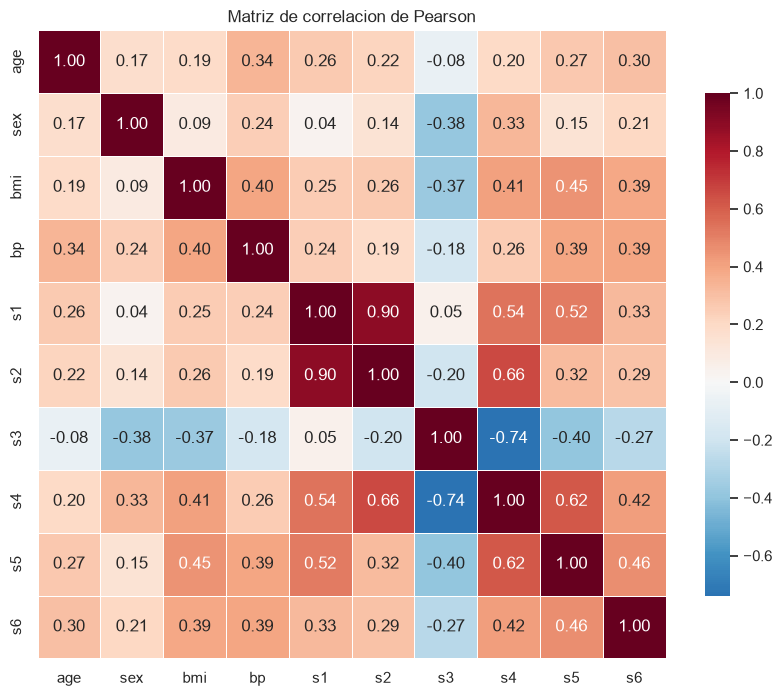

,VIF,diagnostico
s1,59.20,SEVERA
s2,39.19,SEVERA
s3,15.40,SEVERA
s5,10.08,SEVERA
s4,8.89,moderada
bmi,1.51,aceptable
s6,1.48,aceptable
bp,1.46,aceptable
sex,1.28,aceptable
age,1.22,aceptable


In [6]:
corr = X.corr()
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            linewidths=.5, ax=ax, cbar_kws={"shrink": .8})
ax.set_title("Matriz de correlacion de Pearson"); plt.tight_layout(); plt.show()

vif = calcular_vif(X)
display(pd.DataFrame({"VIF": vif.round(2), "diagnostico": vif.map(diagnostico)}))

**El hallazgo central de este caso.** La multicolinealidad no es casual, es
**algebraica**:

- `s4` = colesterol total / HDL = **`s1` / `s3`** por definicion.
- `s2` (LDL) es un **componente** de `s1` (colesterol total).

Las variables lipidicas se contienen unas a otras. La consecuencia se vera en la Fase B:
sus errores estandar se inflan y sus coeficientes dejan de ser interpretables por separado.

## Fase B — Modelamiento estadistico y comparativa

Se entrenan las **dos metodologias exigidas** compartiendo exactamente el mismo
preprocesamiento y la misma particion. La **unica** diferencia entre ellas es la
expansion polinomica, de modo que cualquier diferencia de rendimiento es
atribuible al modelo y no al tratamiento de los datos.

- **Regresion Lineal Multiple**: $\hat{y} = \beta_0 + \sum_i \beta_i z_i$
- **Regresion Polinomica grado 2**: anade terminos cuadraticos $z_i^2$ e
  interacciones $z_i z_j$. Sigue siendo **lineal en los parametros**, que es lo
  que define el metodo.

Se reportan tres medidas: R² de entrenamiento, R² de prueba y **R² de validacion
cruzada 5-fold**. La tercera es la mas fiable, porque promedia cinco particiones
distintas en lugar de depender de una sola.

In [7]:
def evaluar(nombre, grado, X_tr, X_te, y_tr, y_te, escala_dinero=False):
    """Entrena y evalua un modelo; grado=1 es la lineal multiple."""
    pasos = []
    if grado > 1:
        pasos.append(("poly", PolynomialFeatures(degree=grado, include_bias=False)))
    pasos += [("sc", StandardScaler()), ("modelo", LinearRegression())]
    pipe = Pipeline(pasos).fit(X_tr, y_tr)

    p_tr, p_te = pipe.predict(X_tr), pipe.predict(X_te)
    cv = cross_val_score(pipe, X_tr, y_tr, cv=CV, scoring="r2")
    return {
        "modelo": nombre,
        "terminos": pipe.named_steps["modelo"].coef_.size,
        "R2_train": round(r2_score(y_tr, p_tr), 4),
        "R2_test": round(r2_score(y_te, p_te), 4),
        "R2_CV": round(cv.mean(), 4),
        "CV_std": round(cv.std(), 4),
        "brecha": round(r2_score(y_tr, p_tr) - cv.mean(), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_te, p_te)), 4),
        "MAE": round(mean_absolute_error(y_te, p_te), 4),
    }, pipe

In [8]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25, random_state=RANDOM_STATE)
print(f"Entrenamiento: {len(X_tr)}   Prueba: {len(X_te)}   (75 / 25)")
print("\nAviso metodologico: con solo 111 muestras de prueba el R2 de test es ruidoso,")
print("por eso toda comparacion se hace sobre la validacion cruzada 5-fold.")

Entrenamiento: 331   Prueba: 111   (75 / 25)

Aviso metodologico: con solo 111 muestras de prueba el R2 de test es ruidoso,
por eso toda comparacion se hace sobre la validacion cruzada 5-fold.


### Fase B.1 — Regresion Lineal Multiple

In [9]:
m_lin, pipe_lin = evaluar("Lineal multiple (OLS)", 1, X_tr, X_te, y_tr, y_te)
pd.Series(m_lin).to_frame("valor")

,valor
modelo,Lineal multiple (OLS)
terminos,10
R2_train,0.519
R2_test,0.4849
R2_CV,0.4606
CV_std,0.0851
brecha,0.0584
RMSE,53.3696
MAE,41.5485


#### Significancia estadistica de los coeficientes

Prueba *t* sobre los coeficientes estandarizados. Es aqui donde se **mide** el efecto de la multicolinealidad detectada en la Fase A.

In [10]:
from scipy import stats

sc = StandardScaler().fit(X_tr)
A = np.column_stack([np.ones(len(X_tr)), sc.transform(X_tr)])
beta = np.linalg.lstsq(A, y_tr, rcond=None)[0]
resid = y_tr - A @ beta
gl = len(A) - A.shape[1]
cov = (resid @ resid / gl) * np.linalg.inv(A.T @ A)
se = np.sqrt(np.diag(cov))
t = beta / se
p = 2 * (1 - stats.t.cdf(np.abs(t), gl))

tabla = pd.DataFrame({"coef": beta.round(4), "error_std": se.round(4),
                      "t": t.round(2), "p_valor": p.round(4)},
                     index=["intercepto"] + list(X.columns))
tabla["signif"] = ["***" if v < .001 else "**" if v < .01 else "*" if v < .05 else ""
                   for v in p]
display(tabla)
print("Significativas al 5 %: " + ", ".join(v for v, q in zip(X.columns, p[1:]) if q < .05))

,coef,error_std,t,p_valor,signif
intercepto,154.3444,3.0142,51.21,0.0000,***
age,2.2151,3.3234,0.67,0.5056,
sex,-11.5145,3.3670,-3.42,0.0007,***
bmi,25.0770,3.7263,6.73,0.0000,***
bp,18.2493,3.5898,5.08,0.0000,***
s1,-44.1446,22.2102,-1.99,0.0477,*
s2,24.5139,17.9831,1.36,0.1738,
s3,5.4976,11.2118,0.49,0.6242,
s4,13.0068,9.2005,1.41,0.1584,
s5,33.3798,9.4361,3.54,0.0005,***


Significativas al 5 %: sex, bmi, bp, s1, s5


Observa los **errores estandar**: `s1` tiene 22.21 y `s2` 17.98, frente a 3.3–3.7 de `age`, `sex` o `bmi`. Son entre 5 y 7 veces mayores, y son justamente las variables de VIF mas alto. Eso es exactamente lo que hace la multicolinealidad: **inflar la varianza de los estimadores**. El modelo sigue siendo valido para *predecir*, pero no para *explicar* el efecto aislado de cada lipido.

### Fase B.2 — Regresion Polinomial

Se exploran los grados 1 a 3, con y sin regularizacion Ridge, para cuantificar el sobreajuste.

In [11]:
from sklearn.linear_model import RidgeCV

filas = []
for grado in (1, 2, 3):
    m, _ = evaluar(f"Grado {grado} — OLS", grado, X_tr, X_te, y_tr, y_te)
    filas.append(m)
    pasos = [("poly", PolynomialFeatures(degree=grado, include_bias=False)),
             ("sc", StandardScaler()),
             ("modelo", RidgeCV(alphas=np.logspace(-2, 5, 71), cv=CV))]
    pipe = Pipeline(pasos).fit(X_tr, y_tr)
    cv = cross_val_score(pipe, X_tr, y_tr, cv=CV, scoring="r2")
    filas.append({"modelo": f"Grado {grado} — Ridge (a={pipe.named_steps['modelo'].alpha_:.2f})",
                  "terminos": pipe.named_steps["modelo"].coef_.size,
                  "R2_train": round(r2_score(y_tr, pipe.predict(X_tr)), 4),
                  "R2_test": round(r2_score(y_te, pipe.predict(X_te)), 4),
                  "R2_CV": round(cv.mean(), 4), "CV_std": round(cv.std(), 4),
                  "brecha": round(r2_score(y_tr, pipe.predict(X_tr)) - cv.mean(), 4),
                  "RMSE": round(np.sqrt(mean_squared_error(y_te, pipe.predict(X_te))), 4),
                  "MAE": round(mean_absolute_error(y_te, pipe.predict(X_te)), 4)})

pd.DataFrame(filas).set_index("modelo")

,terminos,R2_train,R2_test,R2_CV,CV_std,brecha,RMSE,MAE
modelo,,,,,,,,
Grado 1 — OLS,10,0.5190,0.4849,0.4606,0.0851,0.0584,53.3696,41.5485
Grado 1 — Ridge (a=1.58),10,0.5185,0.4862,0.4597,0.0844,0.0587,53.3016,41.4905
Grado 2 — OLS,65,0.6048,0.4242,0.2979,0.1142,0.3069,56.4248,44.0300
Grado 2 — Ridge (a=25.12),65,0.5373,0.4911,0.4611,0.0832,0.0761,53.0488,41.5854
Grado 3 — OLS,285,0.8960,-8.0873,-171.1188,167.4893,172.0149,224.1651,151.0990
Grado 3 — Ridge (a=199.53),285,0.5361,0.4942,0.4603,0.0834,0.0758,52.8879,41.6342


### Fase B.3 — Comparativa y curva de validacion

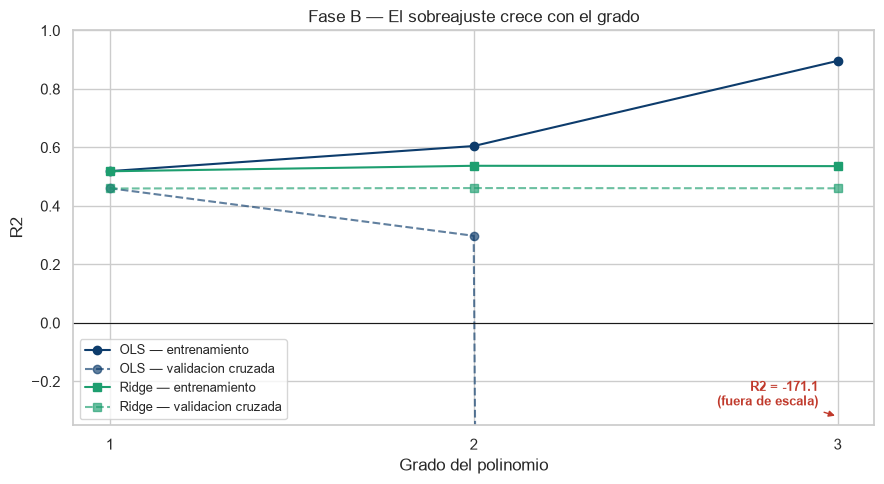

In [12]:
res = pd.DataFrame(filas)
ols = res[res.modelo.str.contains("OLS")]
rid = res[res.modelo.str.contains("Ridge")]
g = [1, 2, 3]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(g, ols.R2_train, "o-", c="#0d3c6c", label="OLS — entrenamiento")
ax.plot(g, ols.R2_CV, "o--", c="#0d3c6c", alpha=.65, label="OLS — validacion cruzada")
ax.plot(g, rid.R2_train, "s-", c="#1d9e6f", label="Ridge — entrenamiento")
ax.plot(g, rid.R2_CV, "s--", c="#1d9e6f", alpha=.65, label="Ridge — validacion cruzada")
ax.set_ylim(-.35, 1); ax.axhline(0, c="k", lw=.8)
ax.set_xticks(g); ax.set_xlabel("Grado del polinomio"); ax.set_ylabel("R2")
ax.set_title("Fase B — El sobreajuste crece con el grado")
for gr, v in zip(g, ols.R2_CV):
    if v < -.35:
        ax.annotate(f"R2 = {v:.1f}\n(fuera de escala)", (gr, -.32), xytext=(-14, 8),
                    textcoords="offset points", ha="right", fontsize=9, color="#c0392b",
                    fontweight="bold", arrowprops=dict(arrowstyle="-|>", color="#c0392b"))
ax.legend(loc="lower left", fontsize=9); plt.tight_layout(); plt.show()

### Conclusion del Caso 3

El polinomio de grado 3 sin regularizar alcanza el **mejor R² de entrenamiento de todo el
estudio (0.8960)** y es, con enorme diferencia, **el peor modelo fuera de la muestra**
(R² de prueba −8.09, validacion cruzada −171.12). Un R² negativo significa que predice
**peor que responder siempre la media**. Es el argumento definitivo contra evaluar un
modelo por su ajuste en entrenamiento.

Con Ridge el sobreajuste desaparece en los tres grados, pero el resultado **converge al
del modelo lineal** (R² de CV ≈ 0.460): la penalizacion no extrae informacion de los
terminos polinomiales, los neutraliza.

La diferencia entre el mejor lineal (0.4606) y el mejor polinomial (0.4611) es de
**+0.0005**, frente a una desviacion entre particiones de ±0.083. Son **estadisticamente
indistinguibles**, y por parsimonia se recomienda la **Regresion Lineal Multiple**: mismo
rendimiento con 10 terminos en lugar de 65 y coeficientes interpretables.